# Updated version:
### Split the time window in window of max 1h to keep a somewhat consistent antenna pattern

Get the time window

In [1]:
from astropy.time import Time
import pandas as pd
import numpy as np

EM_samp = pd.read_csv('/home/stu_jamsin/jamsin/add_files/Bu2019lm_posterior_samples.dat', delimiter=' ', dtype=np.float32)


# 1. Use 170817 merger as ref time (in MJD) bc we do not have Mattia's photometry file
t_ref = 57982.52851851852  + 0.03538402356207371 # first observation of Bulla file

# 2. Calculate 1 sigma interval (16th and 84th percentiles) of the timeshift samples
p16, p50, p84 = np.percentile(EM_samp['timeshift'], [15.865, 50, 84.135])

# 3. Définir la fenêtre temporelle
t_start = t_ref + p50 + p16
t_end = t_ref - p50 - p84

print(f"Médiane : {p50}")
print(f"Search range (1-sigma) : {t_start} à {t_end}")

# convert to gps time
time_mjd = (t_start, t_end)
time_gps = Time(time_mjd, format='mjd').gps

print(f"MJD time: {time_mjd}")
print(f"GPS time: {int(time_gps[0])} to {int(time_gps[1])}")
print("tt:", int((time_gps[0]+time_gps[1])/2))

Médiane : -0.03538402356207371
Search range (1-sigma) : 57982.482698047854 à 57982.624885558405
MJD time: (np.float64(57982.482698047854), np.float64(57982.624885558405))
GPS time: 1187004923 to 1187017208
tt: 1187011065


Generate the template bank

<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3950334/1540104724.py:21: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Mass 1 ($M_{\odot}$)')
/tmp/ipykernel_3950334/1540104724.py:22: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Mass 2 ($M_{\odot}$)')


1 sigma interval for mass 1: [1.31815934 1.48377608]
1 sigma interval for mass 2: [1.15255446 1.34781509]


2026-03-12T15:12:18.564+01:00 INFO : Obtaining PSD
2026-03-12T15:12:18.645+01:00 INFO : Calculating metric
2026-03-12T15:12:20.072+01:00 INFO : Calculating covariance matrix
2026-03-12T15:12:21.483+01:00 INFO : Estimating extent of parameter space
2026-03-12T15:12:28.385+01:00 INFO : Calculating lattice
2026-03-12T15:12:31.768+01:00 INFO : 776 points in the lattice
2026-03-12T15:12:34.516+01:00 INFO : Sorting guide points
2026-03-12T15:12:36.360+01:00 INFO : Converting to physical points
2026-03-12T15:12:36.643+01:00 INFO : Writing output to file /home/stu_jamsin/jamsin/PYCBC/splitwindow/bank.hdf
2026-03-12T15:12:36.645+01:00 INFO : Done


Number of templates in the geometric bank: 747


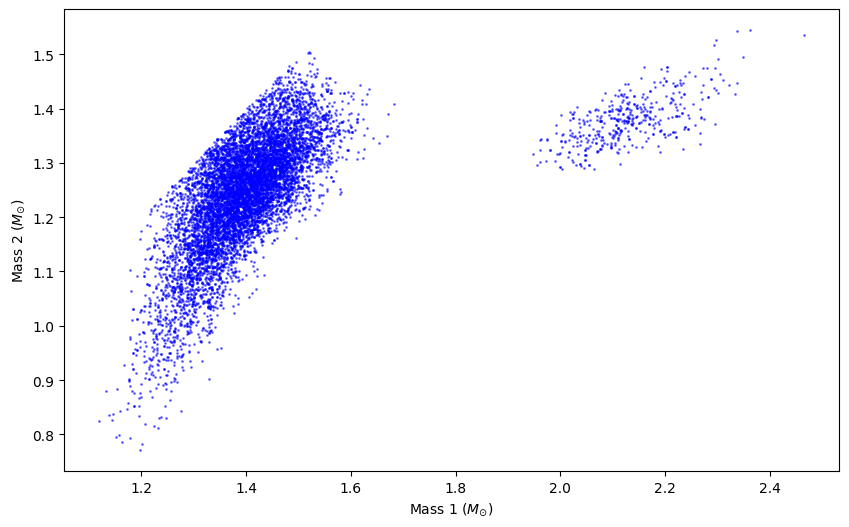

In [2]:
# try to generate a template bank based on the resampling posterior of 170817 
import pandas as pd
import subprocess
import h5py
import matplotlib.pyplot as plt
import numpy as np

sample = pd.read_csv("/home/stu_jamsin/jamsin/test170817/resamp_bulla/posterior_samples.dat", delimiter=' ', dtype=np.float32)

# use that to generate the template bank:
OUT_FILE = '/home/stu_jamsin/jamsin/PYCBC/splitwindow/bank.hdf'

# transforme m chirp q en m1 m2
m1 = sample['chirp_mass'].values * (1 + sample['mass_ratio'].values)**(1/5) / (sample['mass_ratio'].values)**(3/5)
m2 = sample['chirp_mass'].values * (1 + sample['mass_ratio'].values)**(1/5) * (sample['mass_ratio'].values)**(2/5)

# plot m1 m2 bivariate distribution

plt.figure(figsize=(10, 6))
plt.title('Bivariate Distribution of Mass 1 and Mass 2 from Resampled Posterior')
plt.scatter(m1, m2, s=1, alpha=0.5, c='blue')
plt.xlabel('Mass 1 ($M_{\odot}$)')
plt.ylabel('Mass 2 ($M_{\odot}$)')

# print the 1 sigma interval 
print("1 sigma interval for mass 1:", np.percentile(m1, [16, 84]))
print("1 sigma interval for mass 2:", np.percentile(m2, [16, 84]))


CMD = ['pycbc_geom_nonspinbank',
     "--min-mass1", f"{np.percentile(m1,16):.4f}",     
     "--max-mass1",  f"{np.percentile(m1, 84):.4f}",     
     "--min-mass2", f"{np.percentile(m2, 16):.4f}",     
     "--max-mass2", f"{np.percentile(m2, 84):.4f}",     
     "--f-low", "30.0",     
     "--f-upper", "2048.0", 
     "--delta-f", "0.01",     
     "--pn-order", "threePointFivePN",     
     "--min-match", "0.97",
     "--psd-model", "aLIGOZeroDetHighPower",     
     "--output-file", f"{OUT_FILE}", 
     "--verbose"]

subprocess.run(CMD, check=True, cwd='/home/stu_jamsin/jamsin/PYCBC/splitwindow')

# Open the geometric bank file to get the numb of template
bank = h5py.File(OUT_FILE, 'r')
num_templates = len(bank['mass1'][:])
print(f"Number of templates in the geometric bank: {num_templates}")

Split it for parrallelization

In [6]:
# split it
NUM_SPLIT = 10
TEMPLATE_PER_BANK = int(np.ceil(num_templates / NUM_SPLIT))
split_CMD = ["pycbc_hdf5_splitbank",
    "--bank-file", f"{OUT_FILE}",
    "--output-prefix", "/home/stu_jamsin/jamsin/PYCBC/splitwindow/split_bank_",
    "--templates-per-bank", f"{TEMPLATE_PER_BANK}"]

subprocess.run(split_CMD, check=True, cwd='/home/stu_jamsin/jamsin/PYCBC/splitwindow')

CompletedProcess(args=['pycbc_hdf5_splitbank', '--bank-file', '/home/stu_jamsin/jamsin/PYCBC/splitwindow/bank.hdf', '--output-prefix', '/home/stu_jamsin/jamsin/PYCBC/splitwindow/split_bank_', '--templates-per-bank', '75'], returncode=0)

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3950334/1460509009.py:17: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Mass 1 ($M_{\odot}$)')
/tmp/ipykernel_3950334/1460509009.py:18: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('Mass 2 ($M_{\odot}$)')
/tmp/ipykernel_3950334/1460509009.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(m1, m2, s=5, c=col[i])


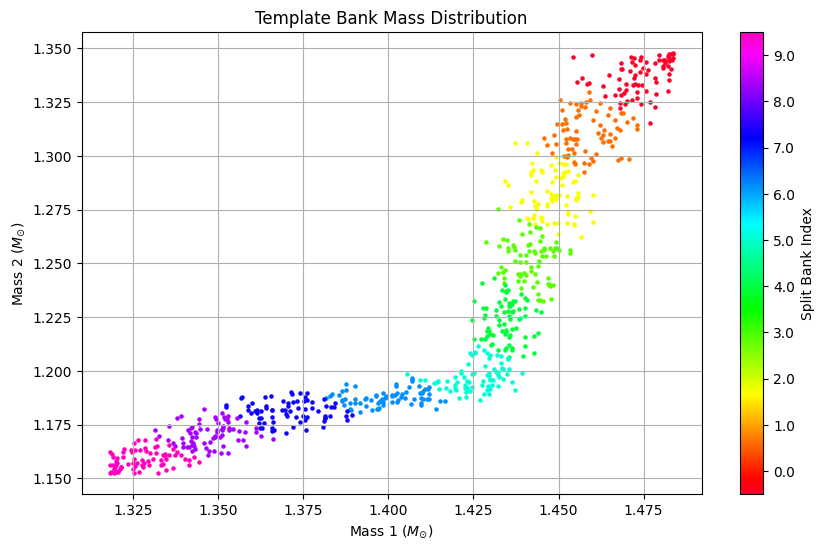

In [7]:
# loop over the split template bank to plot 
import matplotlib.colors as mcolors
norm=mcolors.Normalize(vmin=0, vmax=NUM_SPLIT)
cmap = plt.get_cmap('gist_rainbow')
col = cmap(np.linspace(0,1,NUM_SPLIT))
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(NUM_SPLIT):
    bank = h5py.File(f"/home/stu_jamsin/jamsin/PYCBC/splitwindow/split_bank_{i}.hdf", 'r')
    # Plot the template bank masses
    m1 = bank['mass1'][:]
    m2 = bank['mass2'][:]

    ax.scatter(m1, m2, s=5, c=col[i])
cbar=plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label('Split Bank Index')
cbar.set_ticks(np.arange(0.5,NUM_SPLIT+0.5,1))
ax.set_xlabel('Mass 1 ($M_{\odot}$)')
ax.set_ylabel('Mass 2 ($M_{\odot}$)')
ax.set_title('Template Bank Mass Distribution')
ax.grid(True)
cbar.set_ticklabels(str(idx) for idx in np.arange(0.,NUM_SPLIT,1))
plt.show()

Divide in sub window

In [9]:
num_banks = NUM_SPLIT

global_start = int(time_gps[0])
global_end = int(time_gps[1])
chunk_length = 3600 # 1 hour max length
overlap = 16 # Accounts for 8s padding at start and 8s at end

with open('/home/stu_jamsin/jamsin/PYCBC/splitwindow/job_arguments.txt', 'w') as f:
    for bank in range(num_banks):
        current_start = global_start
        while current_start < global_end:
            current_end = min(current_start + chunk_length, global_end)
            tt = (current_start + current_end) // 2 #for the antenna pattern
            # Write: BANK_NUM START_TIME END_TIME
            f.write(f"{bank} {current_start} {current_end} {tt}\n")
            
            if current_end == global_end:
                break
            
            # Step back by the overlap amount for the next chunk
            current_start = current_end - overlap

print("Generated job_arguments.txt")

Generated job_arguments.txt


# Make a new sub and sh file for condor
### Content of ``run_split_search.sh``:
```
#!/bin/bash

source /opt/conda/etc/profile.d/conda.sh
conda activate fiesta

BANK_NUM=$1
START_TIME=$2
END_TIME=$3
TT=$4

pycbc_multi_inspiral \
     -v \
     --instruments H1 L1 \
     --bank-file /home/stu_jamsin/jamsin/PYCBC/splitwindow/split_bank_${BANK_NUM}.hdf \
     --channel-name H1:GWOSC-4KHZ_R1_STRAIN L1:GWOSC-4KHZ_R1_STRAIN \
     --frame-files H1:/home/stu_jamsin/jamsin/jupyter_nb/H1_READY.gwf L1:/home/stu_jamsin/jamsin/jupyter_nb/L1_READY.gwf \
     --gps-start-time H1:${START_TIME} L1:${START_TIME} h1:${START_TIME} l1:${START_TIME} \
     --gps-end-time H1:${END_TIME} L1:${END_TIME} h1:${END_TIME} l1:${END_TIME} \
     --ra 3.4461587900190143 \
     --dec -0.4080838827694336 \
     --trigger-time ${TT} \
     --low-frequency-cutoff 30.0 \
     --approximant TaylorF2 \
     --order 7 \
     --sample-rate H1:4096 L1:4096 h1:4096 l1:4096 \
     --pad-data H1:8 L1:8 h1:8 l1:8 \
     --segment-length H1:256 L1:256 h1:256 l1:256 \
     --segment-start-pad H1:8 L1:8 h1:8 l1:8 \
     --segment-end-pad H1:8 L1:8 h1:8 l1:8 \
     --psd-estimation H1:median L1:median h1:median l1:median \
     --psd-segment-length H1:16 L1:16 h1:16 l1:16 \
     --psd-segment-stride H1:8 L1:8 h1:8 l1:8 \
     --psd-inverse-length H1:16 L1:16 h1:16 l1:16 \
     --strain-high-pass H1:20 L1:20 h1:20 l1:20 \
     --autogating-threshold H1:50 L1:50 h1:50 l1:50 \
     --autogating-cluster H1:0.5 L1:0.5 h1:0.5 l1:0.5 \
     --autogating-width H1:0.25 L1:0.25 h1:0.25 l1:0.25 \
     --autogating-pad H1:0.25 L1:0.25 h1:0.25 l1:0.25 \
     --autogating-taper H1:0.25 L1:0.25 h1:0.25 l1:0.25 \
     --coinc-threshold 5.5 \
     --sngl-snr-threshold 4.0 \
     --chisq-bins 16 \
     --cluster-method window \
     --cluster-window 1.0 \
     --output /home/stu_jamsin/jamsin/PYCBC/splitwindow/out/triggers_bank${BANK_NUM}_${START_TIME}-${END_TIME}.hdf
```
### Content of ``split_search.sub``:
```
executable = /home/stu_jamsin/jamsin/PYCBC/splitwindow/run_split_search.sh
universe   = vanilla

# Pass the three variables from the text file to the bash script
arguments  = "$(bank) $(start) $(end) $(tt)"

# Ensure logs don't overwrite each other + change path (I went for absolute path just to be sure)
output     = /home/stu_jamsin/jamsin/PYCBC/splitwindow/logs/search_$(bank)_$(start).out
error      = /home/stu_jamsin/jamsin/PYCBC/splitwindow/logs/search_$(bank)_$(start).err
log        = /home/stu_jamsin/jamsin/PYCBC/splitwindow/logs/search_cluster.log

# Request resources (adjust these according to your cluster's limits)
request_cpus   = 1
request_memory = 8GB
request_disk   = 4GB

# Queue a job for every line in the text file we generated
queue bank, start, end from /home/stu_jamsin/jamsin/PYCBC/splitwindow/job_arguments.txt
```

## Analysis of the out files:

In [10]:
import numpy as np
import glob
import os
import h5py

trigger_dir = '/home/stu_jamsin/jamsin/PYCBC/splitwindow/out'
trigger_files = glob.glob(os.path.join(trigger_dir, 'triggers_*.hdf'))
# Filter strictly to the parent directory files
trigger_files = [f for f in trigger_files if os.path.dirname(f) == trigger_dir.rstrip('/')]
trigger_files.sort()

# List to store all triggers from all files
all_triggers = []

print(f"Scanning {len(trigger_files)} files in {trigger_dir}...")

for tfile in trigger_files:
    try:
        with h5py.File(tfile, 'r') as f:
            if 'network' not in f:
                continue
            
            # Use reweighted SNR as ranking statistic
            if 'reweighted_snr' in f['network']:
                ranking_stat_name = 'reweighted_snr'
                snrs = f['network']['reweighted_snr'][:]
            elif 'coherent_snr' in f['network']:
                ranking_stat_name = 'coherent_snr'
                snrs = f['network']['coherent_snr'][:]
            else:
                continue
            
            if len(snrs) == 0:
                continue
            
            # Get other datasets
            coh_snrs = f['network']['coherent_snr'][:] if 'coherent_snr' in f['network'] else np.zeros_like(snrs)
            
            # Time requires careful handling
            # If end_time_gc is available, use it (geocentric time)
            if 'end_time_gc' in f['network']:
                times = f['network']['end_time_gc'][:]
            else:
                # Fallback: recreate from H1 event ids
                # Note: this is slower and complex if done for all, but let's try to grab just what we need later or do it all now
                # For simplicity, if end_time_gc is missing, we might skip time or implement the lookup
                if 'H1_event_id' in f['network'] and 'H1' in f:
                    h1_indices = f['network']['H1_event_id'][:]
                    # We need to load H1 end times.
                    h1_times = f['H1']['end_time'][:]
                    times = h1_times[h1_indices]
                else:
                    times = np.zeros_like(snrs)

            # Store triggers above some threshold to save memory, or just store all if not too many
            # Let's say we keep top 10 from each file
            
            # Get indices of top 10
            if len(snrs) > 10:
                top_indices = np.argsort(snrs)[-10:]
            else:
                top_indices = np.arange(len(snrs))
                
            for idx in top_indices:
                all_triggers.append({
                    'rank_stat': snrs[idx],
                    'coherent_snr': coh_snrs[idx],
                    'time': times[idx],
                    'file': tfile,
                    'idx': idx
                })

    except Exception as e:
        print(f"Error processing {tfile}: {e}")

# Sort all collected triggers by ranking statistic
all_triggers.sort(key=lambda x: x['rank_stat'], reverse=True)

print(f"\nCollected {len(all_triggers)} candidate triggers.")
print(f"Ranking Statistic used: {ranking_stat_name if 'ranking_stat_name' in locals() else 'Unknown'}")

print("\n--- Top 5 Candidate Signals ---")
for i, trig in enumerate(all_triggers[:5]):
    print(f"{i+1}. Rank Stat: {trig['rank_stat']:.4f} | Coherent SNR: {trig['coherent_snr']:.4f} | Time: {trig['time']:.4f} | File: {os.path.basename(trig['file'])}")


Scanning 40 files in /home/stu_jamsin/jamsin/PYCBC/splitwindow/out...

Collected 400 candidate triggers.
Ranking Statistic used: reweighted_snr

--- Top 5 Candidate Signals ---
1. Rank Stat: 19.9947 | Coherent SNR: 29.5974 | Time: 1187008882.4294 | File: triggers_bank1_1187008507-1187012107.hdf
2. Rank Stat: 15.2934 | Coherent SNR: 28.4308 | Time: 1187008882.4287 | File: triggers_bank1_1187008507-1187012107.hdf
3. Rank Stat: 14.9527 | Coherent SNR: 27.6394 | Time: 1187008882.4304 | File: triggers_bank1_1187008507-1187012107.hdf
4. Rank Stat: 10.3352 | Coherent SNR: 24.4803 | Time: 1187008882.4282 | File: triggers_bank1_1187008507-1187012107.hdf
5. Rank Stat: 9.9670 | Coherent SNR: 24.4295 | Time: 1187008882.4309 | File: triggers_bank1_1187008507-1187012107.hdf


Best Candidate Time: 1187008882.43 (GPS)
GW170817 Time: 1187008882.43 (GPS)
Difference: -0.00 s


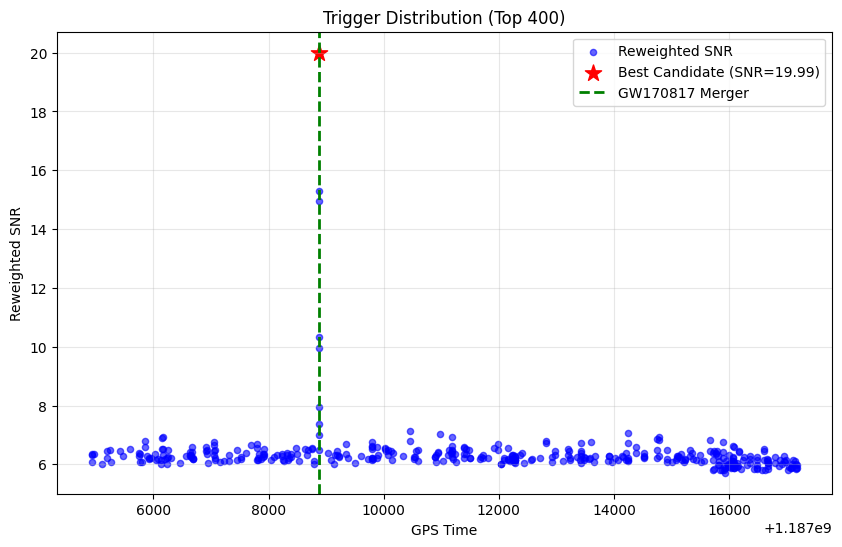

In [11]:
import matplotlib.pyplot as plt

# GW170817 Coalescence Time (GPS)
GW170817_TIME = 1187008882.43
DATA_START_TIME = int(time_gps[0])-16 # start of the window -16s for padding

# Collect plot data (assuming 'all_triggers' is populated from previous cell)
plot_times = [t['time'] for t in all_triggers]
plot_ranks = [t['rank_stat'] for t in all_triggers]
plot_coh = [t['coherent_snr'] for t in all_triggers]

# Find best candidate
best_cand = all_triggers[0]  # Since we sorted them
print(f"Best Candidate Time: {best_cand['time']:.2f} (GPS)")
print(f"GW170817 Time: {GW170817_TIME:.2f} (GPS)")
print(f"Difference: {best_cand['time'] - GW170817_TIME:.2f} s")

plt.figure(figsize=(10, 6))
plt.scatter(plot_times, plot_ranks, alpha=0.6, label='Reweighted SNR', color='blue', s=20)
plt.scatter([best_cand['time']], [best_cand['rank_stat']], color='red', s=150, marker='*', label=f'Best Candidate (SNR={best_cand["rank_stat"]:.2f})')

# Add marker for GW170817 if within range or requested
# Here we show it anyway if feasible, or just note it
if min(plot_times) < GW170817_TIME < max(plot_times):
    plt.axvline(x=GW170817_TIME, color='green', linestyle='--', linewidth=2, label='GW170817 Merger')
else:
    # If it's far, let's just break the axis or extend it? 
    # For now, just plot data as requested "snr accross time"
    pass

plt.xlabel('GPS Time')
plt.ylabel('Reweighted SNR')
plt.title(f'Trigger Distribution (Top {len(plot_times)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
# find the best candidate template parameters
filepath = best_cand['file']
index = best_cand['idx']
# load hdf file
with h5py.File(filepath, 'r') as f:
    idx = f['network']['template_id'][index]

# open the right bank file: split filepath to get the right bank number
bank_num = int(os.path.basename(filepath).split('_')[1].replace('bank', ''))
bank_file = f"/home/stu_jamsin/jamsin/PYCBC/splitwindow/split_bank_{bank_num}.hdf"
# open the bank file to get the template parameters
with h5py.File(bank_file, 'r') as b:
    m1 = b['mass1'][idx]
    m2 = b['mass2'][idx]
    s1z = b['spin1z'][idx] if 'spin1z' in b else 0.0
    s2z = b['spin2z'][idx] if 'spin2z' in b else 0.0    
            
print(f"Candidate Parameters: m1={m1:.3f}, m2={m2:.3f}, spin1z={s1z:.3f}, spin2z={s2z:.3f}")

Candidate Parameters: m1=1.453, m2=1.303, spin1z=0.000, spin2z=0.000
